# YOLO — Session 2 Lab: Custom Training & Applications
### ITI · Instructor: Ahmed Abdelsalam

Train YOLO end-to-end, evaluate it, run your trained model, and explore what else YOLO can do.

**Rules of the lab**
- Made for **Google Colab** — **use a GPU runtime** for training (*Runtime → Change runtime type → GPU*).
- Try first, ask second.
- Done early? Head to the **Challenges**.

## Setup — run this first

In [1]:
!pip install ultralytics -q

from ultralytics import YOLO
import matplotlib.pyplot as plt
from skimage import data
from PIL import Image

Image.fromarray(data.coffee()).save("scene.jpg")
print("Ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ready.


## About the dataset

Building and labelling a full custom dataset takes time, so today we train on **`coco8`** — a tiny 8-image sample dataset that Ultralytics downloads automatically. It's not exciting, but it lets us run the **entire training pipeline** fast and see it work.

> For a real project you'd replace `coco8.yaml` with the path to **your own** `data.yaml` (images + labels you annotated) — every other line stays the same.

## Exercise 1 — Train a model

Start from the pretrained `yolo11n.pt` and train it on `coco8.yaml` for a few epochs. Fill in the `model.train(...)` call with `data="coco8.yaml"`, `epochs=5`, `imgsz=320`.

*(Watch the table it prints — you'll see the loss drop and mAP appear each epoch.)*

In [2]:
# Your code here
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(
    data="coco8.yaml",
    epochs=5,
    imgsz=320
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0, 16, 17, 20, 25, 58])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78b3dadbe240>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

## Exercise 2 — Evaluate the model

Run `model.val()` and print the two headline metrics: `metrics.box.map50` (mAP at 50% overlap) and `metrics.box.map` (mAP50-95, the strict headline number).

In [3]:
# Your code here
metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLO11n summary (fused): 101 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2173.5±1004.4 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.5it/s 0.2s
                   all          4         17      0.684      0.583      0.716      0.421
                person          3         10      0.231        0.5      0.318      0.138
                   dog          1          1      0.661          1      0.995      0.497
                 horse          1          2      0.684          1      0.995      0.547
              elephant          1          2          1          0      0.995      0.347
              umbrella          1          1      0.526   

## Exercise 3 — Predict with your trained model

Your `model` is now trained. Run it on `"scene.jpg"` and show the annotated result (remember `.plot()` returns BGR).


image 1/1 /content/scene.jpg: 224x320 1 cup, 1 dining table, 116.3ms
Speed: 2.5ms preprocess, 116.3ms inference, 2.6ms postprocess per image at shape (1, 3, 224, 320)


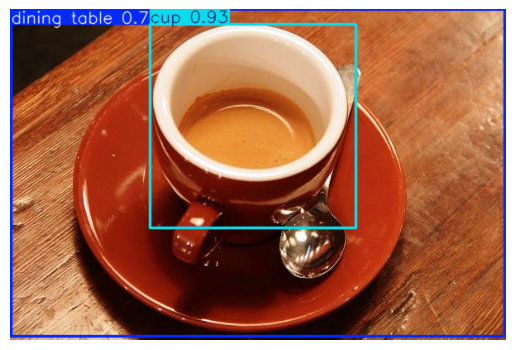

In [4]:
# Your code here
results = model("scene.jpg")

plt.imshow(results[0].plot()[:, :, ::-1])
plt.axis("off")
plt.show()

## Exercise 4 — A simple application: object counter

Applications are usually built on top of detection. Write a function `count_report(image_path)` that runs YOLO and prints a small report like:

```
Report for scene.jpg:
  dining table: 1
  cup: 1
  Total objects: 2
```

Use a fresh pretrained `YOLO("yolo11n.pt")` for reliable detections. Test on `"scene.jpg"`.

In [5]:
# Your code here
model = YOLO("yolo11n.pt")

def count_report(image_path):

    results = model(image_path)[0]

    counts = {}

    for box in results.boxes:

        label = model.names[int(box.cls)]

        counts[label] = counts.get(label, 0) + 1

    print(f"Report for {image_path}:")

    total = 0

    for label, number in counts.items():
        print(f"{label}: {number}")
        total += number

    print("Total objects:", total)


count_report("scene.jpg")


image 1/1 /content/scene.jpg: 448x640 1 cup, 1 dining table, 104.9ms
Speed: 1.8ms preprocess, 104.9ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Report for scene.jpg:
dining table: 1
cup: 1
Total objects: 2


## Exercise 5 — YOLO does more than boxes: segmentation

Segmentation outlines the **exact pixels** of each object, not just a box. It's the same API — just load a `-seg` model. Run `YOLO("yolo11n-seg.pt")` on `"scene.jpg"` and show the annotated result.


image 1/1 /content/scene.jpg: 448x640 1 cup, 2 spoons, 1 dining table, 160.5ms
Speed: 2.1ms preprocess, 160.5ms inference, 5.6ms postprocess per image at shape (1, 3, 448, 640)


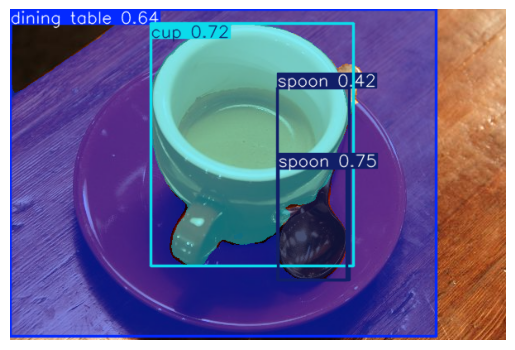

In [6]:
# Your code here
seg_model = YOLO("yolo11n-seg.pt")

results = seg_model("scene.jpg")

plt.imshow(results[0].plot()[:, :, ::-1])
plt.axis("off")
plt.show()

## 🚀 Challenges

Add new cells as needed.

**Challenge A — Count only people.**
Write a function that returns the number of **people** (COCO class 0) in an image, using the `classes=[0]` argument. Test it on an image with a person.

In [7]:
# Your code here
model = YOLO("yolo11n.pt")

def count_people(image_path):

    results = model(image_path, classes=[0])[0]

    return len(results.boxes)

print("People:", count_people("scene.jpg"))


image 1/1 /content/scene.jpg: 448x640 (no detections), 96.5ms
Speed: 2.0ms preprocess, 96.5ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
People: 0


**Challenge B — Compare model sizes.**
Run both `yolo11n.pt` (nano) and `yolo11s.pt` (small) on `scene.jpg`. Print how many objects each finds. Does the bigger model find more?

In [8]:
# Your code here
nano = YOLO("yolo11n.pt")
small = YOLO("yolo11s.pt")

nano_results = nano("scene.jpg")[0]
small_results = small("scene.jpg")[0]

print("YOLO11n Objects:", len(nano_results.boxes))
print("YOLO11s Objects:", len(small_results.boxes))


image 1/1 /content/scene.jpg: 448x640 1 cup, 1 dining table, 112.0ms
Speed: 2.5ms preprocess, 112.0ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/scene.jpg: 448x640 1 cup, 1 spoon, 1 dining table, 297.1ms
Speed: 3.4ms preprocess, 297.1ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
YOLO11n Objects: 2
YOLO11s Objects: 3


**Challenge C — Your own dataset (design task, no code needed).**
In a text cell, describe a custom detector you'd like to build: what classes, roughly how many images you'd collect, and which annotation tool you'd use. Then write the `data.yaml` you would need for it.